In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import os
import time
import ssl
import random   

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)   

ssl._create_default_https_context = ssl._create_unverified_context

train_dir = './dataset_split/train'
val_dir = './dataset_split/val'
test_dir = './dataset_split/test'

In [2]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),     
    transforms.RandomHorizontalFlip(),  
    transforms.RandomRotation(10),      
    transforms.ToTensor(),              
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Libraries loaded and transforms defined!")



train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=test_transforms)

classes = train_dataset.classes
print(f"Classes found: {classes}")


assert classes == val_dataset.classes == test_dataset.classes, \
    "Train/Val/Test folder classes do not match! Please check the folder names."

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training: {len(train_dataset)} | Validation: {len(val_dataset)} | Testing: {len(test_dataset)}")


Libraries loaded and transforms defined!
Classes found: ['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Training: 3372 | Validation: 419 | Testing: 426


In [3]:

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Model will train on: {device}")


model = resnet18(weights=ResNet18_Weights.DEFAULT)


num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(classes))

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

print("Model architecture is set and ready for training!")


Model will train on: mps
Model architecture is set and ready for training!


In [4]:

num_epochs = 10
best_val_acc = 0.0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

print("Training started...")

for epoch in range(num_epochs):
    start_time = time.time()

    # TRAINING PHASE 
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()          
        outputs = model(inputs)        
        loss = criterion(outputs, labels)
        loss.backward()                
        optimizer.step()               

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # VALIDATION PHASE
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_loss / total_val
    val_acc = correct_val / total_val

    scheduler.step()  # learning rate update

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_retinal_model.pth')
        marker = "  <-- best so far, saved"
    else:
        marker = ""

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} [{epoch_time:.0f}s] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}{marker}")

print(f"\nTraining complete. Best Validation Accuracy: {best_val_acc:.4f}")
print("Best model saved as 'best_retinal_model.pth'")


Training started...
Epoch 1/10 [49s] Train Loss: 0.5048, Train Acc: 0.8075 | Val Loss: 0.3866, Val Acc: 0.8592  <-- best so far, saved
Epoch 2/10 [46s] Train Loss: 0.3311, Train Acc: 0.8846 | Val Loss: 0.3998, Val Acc: 0.8544
Epoch 3/10 [46s] Train Loss: 0.3028, Train Acc: 0.8870 | Val Loss: 0.3286, Val Acc: 0.8831  <-- best so far, saved
Epoch 4/10 [46s] Train Loss: 0.2818, Train Acc: 0.8995 | Val Loss: 0.3812, Val Acc: 0.8735
Epoch 5/10 [46s] Train Loss: 0.2430, Train Acc: 0.9090 | Val Loss: 0.3009, Val Acc: 0.9021  <-- best so far, saved
Epoch 6/10 [45s] Train Loss: 0.2298, Train Acc: 0.9158 | Val Loss: 0.2485, Val Acc: 0.9212  <-- best so far, saved
Epoch 7/10 [45s] Train Loss: 0.2087, Train Acc: 0.9220 | Val Loss: 0.2461, Val Acc: 0.9069
Epoch 8/10 [45s] Train Loss: 0.1666, Train Acc: 0.9368 | Val Loss: 0.1886, Val Acc: 0.9356  <-- best so far, saved
Epoch 9/10 [45s] Train Loss: 0.1312, Train Acc: 0.9490 | Val Loss: 0.2184, Val Acc: 0.9284
Epoch 10/10 [45s] Train Loss: 0.1527, Tra

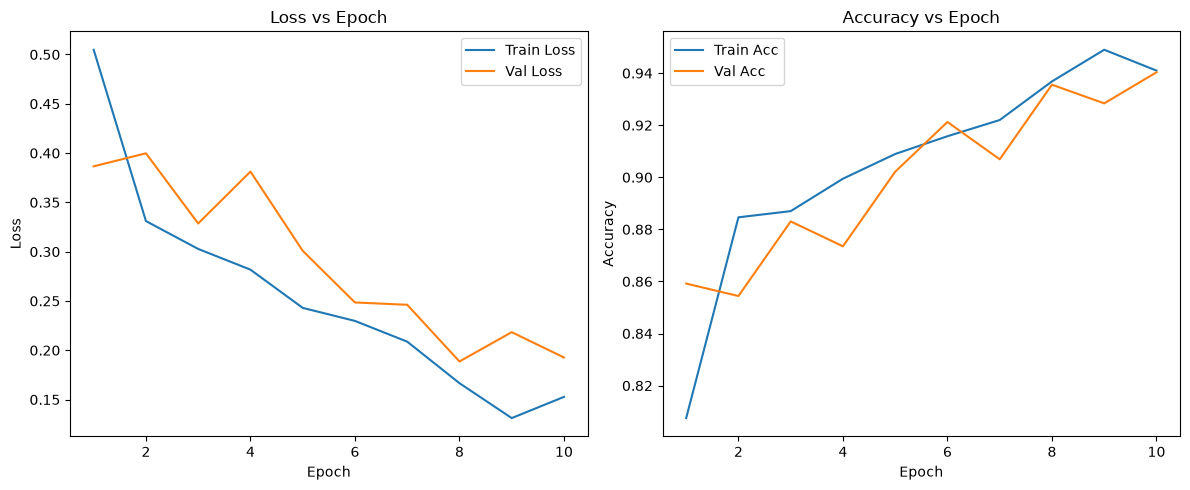

Final Test Accuracy : 0.9296

                      precision    recall  f1-score   support

            cataract       0.95      0.99      0.97       105
diabetic_retinopathy       1.00      0.99      1.00       111
            glaucoma       0.89      0.84      0.86       102
              normal       0.88      0.89      0.88       108

            accuracy                           0.93       426
           macro avg       0.93      0.93      0.93       426
        weighted avg       0.93      0.93      0.93       426

Confusion Matrix (rows=actual, cols=predicted):
['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
[[104   0   1   0]
 [  1 110   0   0]
 [  3   0  86  13]
 [  2   0  10  96]]


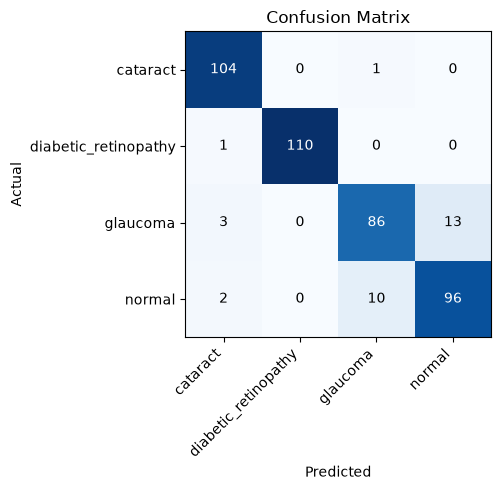

In [5]:

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()



model.load_state_dict(torch.load('best_retinal_model.pth', map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Final Test Accuracy : {test_acc:.4f}\n")


print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix -- rows = actual, columns = predicted
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix (rows=actual, cols=predicted):")
print(classes)
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticklabels(classes)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()